# Irrigation Detection from MoistX Surface Soil Moisture

Identifies **irrigation** and **rain** events from satellite surface SM (0–5 cm).

**Algorithm**
1. Auto-generate a ring buffer around the user's field polygon
2. Download GeoTIFFs for the buffer and field via the MoistX API (cached locally),
   including the per-pixel quality flag. With `EXCLUDE_POOR_QUALITY`, pixel observations
   flagged `poor` (dense vegetation, NDVI ≥ 0.75 — less reliable SM) are dropped before
   any of the steps below
3. Cluster buffer pixels into **reference (non-irrigated)** and **potentially-irrigated**
   groups: K-means on temporal features (mean SM, local jump count, standard deviation)
   picks the low-SM cluster as the reference candidate, then only its calmest pixels —
   the bottom `REF_JUMP_PERCENTILE` by local (non-rain) jump count — are kept as
   reference. This excludes pixels that happen to be low-SM but still show
   irrigation-like jump activity, without requiring the unrealistic "zero jumps ever"
   bar that satellite noise alone would fail
4. Compare the field with the reference on each acquisition (field − reference), skipping
   dates where fewer than `MIN_FIELD_COVERAGE` of field pixels are valid. Because both
   come from the same acquisition, weather and the offset between sensors in harmonized
   data cancel out. Between consecutive dates:
   - field − reference rises by more than `JUMP_THRESHOLD`, the field itself gets
     wetter, and buffer jump fraction < `RAIN_FRACTION` → **irrigation** (the field
     wetted more than its surroundings)
   - field SM rises by more than `JUMP_THRESHOLD` and buffer jump fraction ≥
     `RAIN_FRACTION` → **rain** (widespread event)
   - confidence is scaled down the closer the buffer jump fraction sits to
     `RAIN_FRACTION`, softening the hard cutoff between the two classes
5. Report each event with date, magnitude, and a confidence score (0–1); marker size
   and opacity in the plot also scale with confidence so weak detections are visually
   de-emphasised

The pipeline logic lives in `helpers.py`; the chart is built by `plotting.py` — this
notebook just wires the two together.

> **Note:** Surface SM at 0–5 cm reflects wetting events but not root-zone moisture.
> This notebook is for *retrospective detection* of past irrigation events, not scheduling.

Uses `POST /get/file/soil-moisture` — see [Swagger UI](https://moistx.com/api/docs) /
[ReDoc](https://moistx.com/api/redoc) for the full API reference, and the repo
[README](./README.md#data-license--attribution) for data licensing/attribution terms.

In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from dotenv import load_dotenv
load_dotenv()

from helpers import (
    compute_ring_buffer,
    download_sm_files,
    load_pixel_timeseries,
    compute_pixel_features,
    find_reference_pixels,
    compute_jump_fractions,
    time_centered_smooth,
    detect_events,
    summarise_events,
)
from plotting import plot_field_buffer_map, plot_cluster_map, plot_sm_events

import pandas as pd
import plotly.io as pio

# Interactive chart in Jupyter/VS Code, plus a static PNG copy saved with the output so
# the chart also shows on GitHub (which doesn't run JavaScript). The PNG needs kaleido
# and Chrome (`pip install kaleido`, then `plotly_get_chrome`); without them, charts
# are just interactive.
try:
    pio.to_image({'data': []}, format='png')
    pio.renderers.default = 'plotly_mimetype+png'
except Exception:
    pass


In [2]:
# ── Parameters — edit here ────────────────────────────────────────────────────

API_KEY = os.getenv('MOISTX_API_KEY')
if not API_KEY:
    raise RuntimeError(
        'MOISTX_API_KEY not set — add your key to .env '
        '(get one from https://moistx.com/dashboard)'
    )
BASE_URL  = 'https://moistx.com/api'
CACHE_DIR = './cache'

# Your field polygon in WKT (longitude latitude, WGS84)
# Draw one at https://wktmap.com and paste the result here
FIELD_WKT = (
    'POLYGON((22.10810087 39.44885229, 22.11079675 39.44854834, '
    '22.11048620 39.44678412, 22.10775568 39.44704964, '
    '22.10810087 39.44885229))'
)

# Irrigation season — max 365 days
SEASON_START = '2025-05-01T00:00:00'
SEASON_END   = '2025-09-30T23:59:59'

# Detection parameters
BUFFER_M                = 1500   # ring buffer width in metres (auto-computed from field)
JUMP_THRESHOLD          = 2.5   # vol% rise to flag an event — of field minus reference for
                                # irrigation, of field SM for rain. Keep it above the
                                # retrieval noise (~1 vol%), or sensor noise reads as events
RAIN_FRACTION           = 0.7  # fraction of buffer pixels jumping → classifies event as rain.
                                # Convective summer rain wets only part of the buffer, so
                                # values near 1.0 mislabel rain as irrigation
MIN_FIELD_COVERAGE      = 0.5   # skip dates where fewer than this fraction of field pixels
                                # have a valid value — a mean from a few pixels is unreliable
MIN_IRRIGATION_GAP_DAYS = 5     # consecutive irrigation events closer than this are merged
REF_JUMP_PERCENTILE     = 0.5  # keep only the calmest X% of the low-SM cluster (by local
                                # jump count) as the non-irrigated reference — lower = stricter
REF_SMOOTHING_DAYS      = 6     # ± half this many days, centered in calendar time (not
                                # acquisition count), applied to the reference SM line in
                                # the chart (detection uses the unsmoothed reference)
EXCLUDE_POOR_QUALITY    = True  # drop pixel observations flagged 'poor' (dense vegetation,
                                # NDVI ≥ 0.75) before clustering and detection. In a dense
                                # summer crop this can remove much of the season — set False
                                # to keep them. No effect where quality flags aren't available

In [3]:
field_geom, ring_geom, ring_wkt = compute_ring_buffer(FIELD_WKT, buffer_m=BUFFER_M)
center = [field_geom.centroid.y, field_geom.centroid.x]

plot_field_buffer_map(field_geom, ring_geom, center)


Buffer ring: 836 ha


In [4]:
# Files are cached by (polygon + date range) — re-running skips the API call.
# include_metadata=True also downloads the per-pixel sensors and quality flag files.
buffer_files = download_sm_files(
    ring_wkt, SEASON_START, SEASON_END, CACHE_DIR, API_KEY, BASE_URL, label='buffer',
    include_metadata=True,
)
field_files = download_sm_files(
    FIELD_WKT, SEASON_START, SEASON_END, CACHE_DIR, API_KEY, BASE_URL, label='field',
    include_metadata=True,
)

[buffer] 80 files already cached → cache/ba0c4c579607
[field] 80 files already cached → cache/fc46348c70f8


In [5]:
print('Loading buffer pixels …')
buffer_pixels = load_pixel_timeseries(buffer_files, ring_geom)

print('Loading field pixels …')
field_pixels = load_pixel_timeseries(field_files, field_geom)
n_field_pixels = field_pixels['pixel_id'].nunique()

# Quality filter: drop pixel observations flagged 'poor' (NDVI ≥ 0.75)
if EXCLUDE_POOR_QUALITY:
    if buffer_pixels['quality'].notna().any() or field_pixels['quality'].notna().any():
        for name, px in (('buffer', buffer_pixels), ('field', field_pixels)):
            print(f'{name:<6}: excluding {(px["quality"] == "poor").mean():.0%} '
                  f'of pixel observations flagged poor quality')
        buffer_pixels = buffer_pixels[buffer_pixels['quality'] != 'poor']
        field_pixels  = field_pixels[field_pixels['quality'] != 'poor']
    else:
        print('No quality flags available for this region — nothing excluded')

# Field mean SM per acquisition, plus the cross-pixel std as a stability/heterogeneity
# measure — a small std means the field wetted uniformly, a large one means only part
# of it responded
field_agg    = field_pixels.groupby('datetime')['sm'].agg(['mean', 'std']).sort_index()
field_ts     = field_agg['mean'].round(1).rename('field_sm')
field_sm_std = field_agg['std'].fillna(0).round(2).rename('field_sm_std')

# Fraction of field pixels with a valid value on each date (after the quality filter)
field_coverage = field_pixels.groupby('datetime').size().sort_index() / n_field_pixels

n_buf_dates  = buffer_pixels['datetime'].nunique()
n_buf_pixels = buffer_pixels['pixel_id'].nunique()
print(f'Field : {len(field_ts)} acquisitions, {n_field_pixels} pixels '
      f'({(field_coverage < MIN_FIELD_COVERAGE).sum()} acquisitions below '
      f'{MIN_FIELD_COVERAGE:.0%} coverage, skipped in detection)')
print(f'Buffer: {n_buf_dates} acquisitions, {n_buf_pixels} pixels')

Loading buffer pixels …
  Loaded 80/80 files …
Loading field pixels …
  Loaded 80/80 files …
No quality flags available for this region — nothing excluded
Field : 59 acquisitions, 119 pixels (1 acquisitions below 50% coverage, skipped in detection)
Buffer: 61 acquisitions, 20736 pixels


In [6]:
# Buffer-wide jump fractions are needed before clustering: a pixel's *local* jump
# count (used to pick reference pixels) should exclude dates where most of the buffer
# jumped together, since that's rain, not irrigation.
jump_fracs = compute_jump_fractions(buffer_pixels, jump_thr=JUMP_THRESHOLD)

features, ref_ids = find_reference_pixels(
    compute_pixel_features(
        buffer_pixels, jump_thr=JUMP_THRESHOLD,
        jump_fractions=jump_fracs, rain_fraction=RAIN_FRACTION,
    ),
    k=2,
    ref_jump_percentile=REF_JUMP_PERCENTILE,
)

plot_cluster_map(field_geom, features, center)


Pixel features computed: 20736 pixels with ≥3 observations
Low-SM cluster      : 5308/20736 pixels  (mean SM 19.6 vol%  vs.  21.3 vol% other cluster)
Reference (strict)  : 2951/5308 pixels with jump_count <= 7  (calmest 50% of the low-SM cluster by local jump activity) kept as non-irrigated reference


In [7]:
# Reference mean SM (non-irrigated pixels), plus cross-pixel std for a variability band
ref_pixel_rows = buffer_pixels[buffer_pixels['pixel_id'].isin(ref_ids)]
ref_agg        = ref_pixel_rows.groupby('datetime')['sm'].agg(['mean', 'std']).sort_index()
ref_ts_raw     = ref_agg['mean'].round(1).rename('ref_sm')
ref_sm_std_raw = ref_agg['std'].fillna(0).round(2).rename('ref_sm_std')

# Smoothed reference, for the chart only — centered in calendar time
# (±REF_SMOOTHING_DAYS/2), not acquisition count, since acquisitions are irregularly
# spaced. The std is smoothed the same way so the ± band stays a coherent shape.
ref_ts     = time_centered_smooth(ref_ts_raw, REF_SMOOTHING_DAYS).round(1)
ref_sm_std = time_centered_smooth(ref_sm_std_raw, REF_SMOOTHING_DAYS).round(2)

# Detection compares field and reference on the *same* acquisition, so it uses the
# unsmoothed reference: whatever both share that day (weather, and the offset between
# sensors in harmonized data) cancels out, leaving wetting specific to the field.
# jump_fracs was already computed above (reused here so buffer-wide rain dates are
# identified consistently for both reference-pixel selection and event detection)
events_df = detect_events(
    field_ts, ref_ts_raw, jump_fracs,
    jump_thr=JUMP_THRESHOLD,
    rain_fraction=RAIN_FRACTION,
    min_irrigation_gap_days=MIN_IRRIGATION_GAP_DAYS,
    field_coverage=field_coverage,
    min_field_coverage=MIN_FIELD_COVERAGE,
)


In [8]:
events_table = summarise_events(events_df)
events_table


──────────────────────────────────────────────────
Field irrigated      : Yes
Irrigation events    : 3
  2025-07-03  Δ vs reference=+4.4 vol%  (field Δ=+1.3)  confidence=0.85
  2025-07-09  Δ vs reference=+2.6 vol%  (field Δ=+3.1)  confidence=0.45
  2025-07-26  Δ vs reference=+3.3 vol%  (field Δ=+1.6)  confidence=0.88
Rain events          : 4
  2025-05-16  Δ=+2.6 vol%  confidence=0.64
  2025-05-27  Δ=+4.7 vol%  confidence=0.77
  2025-08-02  Δ=+4.0 vol%  confidence=0.67
  2025-08-07  Δ=+8.0 vol%  confidence=0.97
──────────────────────────────────────────────────


,datetime,event_type,field_sm,field_delta,ref_delta,anomaly_delta,buffer_fraction,field_coverage,confidence
0,2025-05-16 09:30:00,rain,27.6,2.6,3.5,-0.9,0.87,1.0,0.64
1,2025-05-27 09:30:00,rain,27.5,4.7,4.0,0.7,0.88,1.0,0.77
2,2025-07-03 09:30:00,irrigation,18.7,1.3,-3.1,4.4,0.15,1.0,0.85
3,2025-07-09 09:30:00,irrigation,19.3,3.1,0.5,2.6,0.49,1.0,0.45
4,2025-07-26 09:30:00,irrigation,19.9,1.6,-1.7,3.3,0.04,1.0,0.88
5,2025-08-02 09:30:00,rain,23.6,4.0,4.7,-0.7,0.83,1.0,0.67
6,2025-08-07 09:30:00,rain,27.1,8.0,6.6,1.4,0.98,1.0,0.97


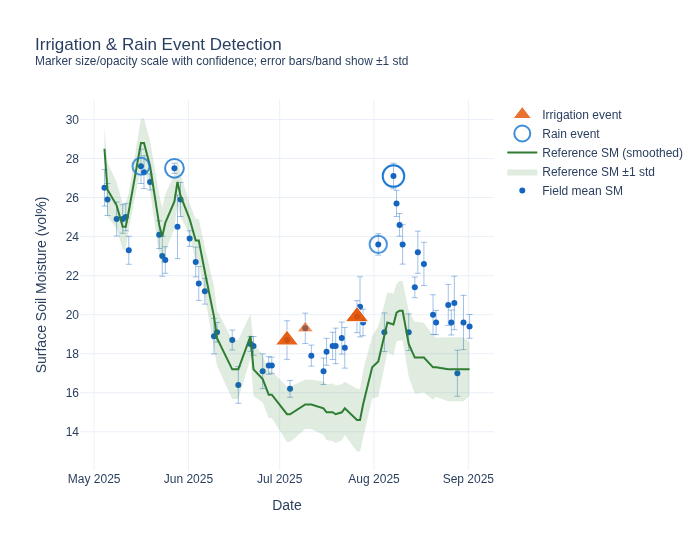

In [9]:
rain_ev = events_df[events_df['event_type'] == 'rain']
irr_ev  = events_df[events_df['event_type'] == 'irrigation']

fig = plot_sm_events(field_ts, field_sm_std, ref_ts, ref_sm_std, rain_ev, irr_ev)
fig.show()
